# SimpleRepeatSeq — Notebook 02
## Experimentos: Encoding × Preprocesamiento × Modelo

Carga los encodings generados por `01_load_data.ipynb` y ejecuta la grilla completa de experimentos:
- **6 encodings** × **3 preprocesadores** × **8 modelos** = 144 combinaciones
- Validación cruzada estratificada 10-fold
- Métricas: Accuracy, F1-weighted, Precision, Recall, AUC
- Figuras obligatorias: heatmap comparativo, curvas ROC, matrices de confusión, tiempo vs. dimensionalidad

**Prerequisito:** ejecutar `01_load_data.ipynb` primero.

In [1]:
!pip install -q biopython scikit-learn xgboost tensorflow scikeras seaborn joblib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import os
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASES = ['no_simpleSeq', 'simpleSeq']

# Rutas relativas al repo (el notebook vive en notebooks/)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(REPO_ROOT, 'data', 'encoded')
FIG_DIR   = os.path.join(REPO_ROOT, 'figures')
MODEL_DIR = os.path.join(REPO_ROOT, 'models')

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'DATA_DIR  : {DATA_DIR}')
print(f'FIG_DIR   : {FIG_DIR}')
print(f'MODEL_DIR : {MODEL_DIR}')

In [3]:
# Verificar que los encodings estén disponibles
y = np.load(os.path.join(DATA_DIR, 'y_labels.npy')).astype(int)
ENCODINGS = ['dax', 'complementary', 'eiip', 'kmer3', 'kmer4', 'kmer6']

for enc in ENCODINGS:
    path = os.path.join(DATA_DIR, f'X_{enc}.npy')
    if os.path.exists(path):
        X = np.load(path)
        print(f'X_{enc}: {X.shape}')
    else:
        print(f'FALTA: X_{enc}.npy — ejecuta 01_load_data.ipynb')

print(f'\ny: {y.shape}  distribución: {dict(zip(*np.unique(y, return_counts=True)))}')

X_dax: (888, 500)
X_complementary: (888, 500)
X_eiip: (888, 500)
X_kmer3: (888, 125)
X_kmer4: (888, 625)
X_kmer6: (888, 15625)

y: (888,)  distribución: {np.int64(0): np.int64(444), np.int64(1): np.int64(444)}


---
## Definición de modelos y pipelines

### DNN (deep learning)
La función `make_keras_model` recibe `meta` automáticamente de scikeras,
que contiene `n_features_in_` con la dimensionalidad real del fold de entrenamiento.
Esto resuelve el error de configuración cuando la dimensión varía entre encodings o tras PCA.

In [ ]:
def make_keras_model(meta=None):
    """Red neuronal fully-connected. scikeras inyecta `meta` con n_features_in_.
    Usa 2 salidas softmax para compatibilidad con cross_validate de sklearn."""
    n_features = meta['n_features_in_'] if meta is not None else 125
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(n_features,)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(2, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_models():
    return {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', probability=True, random_state=SEED),
        'LR' : LogisticRegression(max_iter=2000, random_state=SEED),
        'LDA': LinearDiscriminantAnalysis(),
        'NB' : GaussianNB(),
        'RF' : RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
        'XGB': XGBClassifier(n_estimators=200, random_state=SEED,
                             eval_metric='logloss', verbosity=0),
        'DNN': KerasClassifier(model=make_keras_model,
                               epochs=40, batch_size=32, verbose=0, random_state=SEED),
    }


def build_pipeline(preproc, model):
    """Scaler y PCA se ajustan sólo con el train de cada fold (evita data leakage)."""
    steps = []
    if preproc == 'scaled':
        steps.append(('scaler', StandardScaler()))
    elif preproc == 'pca':
        steps.append(('scaler', StandardScaler()))
        steps.append(('pca', PCA(n_components=0.96, random_state=SEED)))
    steps.append(('model', model))
    return Pipeline(steps)


def auc_scorer(estimator, X, y):
    """Scorer AUC compatible con todos los modelos, incluido scikeras/Keras."""
    proba = estimator.predict_proba(X)
    if proba.ndim == 2:
        proba = proba[:, 1]
    return roc_auc_score(y, proba)


SCORING = {
    'accuracy' : 'accuracy',
    'f1'       : 'f1_weighted',
    'precision': 'precision_weighted',
    'recall'   : 'recall_weighted',
    'auc'      : auc_scorer,
}

PREPROCS = ['raw', 'scaled', 'pca']
N_SPLITS = 10
kf_cv    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

n_combos = len(ENCODINGS) * len(PREPROCS) * len(build_models())
print(f'{len(ENCODINGS)} encodings × {len(PREPROCS)} preprocs × {len(build_models())} modelos = {n_combos} combinaciones')

---
## Bucle principal: CV 10-fold estratificada

> El DNN usa `n_jobs=1` para evitar conflictos de serialización con TensorFlow
> en entornos multiprocess. Los demás modelos usan `n_jobs=-1`.

In [5]:
resultados = []
t_global   = time.time()

for enc_name in ENCODINGS:
    X_enc = np.load(os.path.join(DATA_DIR, f'X_{enc_name}.npy')).astype(np.float32)
    y_enc = np.load(os.path.join(DATA_DIR, 'y_labels.npy')).astype(int)
    n_feat = X_enc.shape[1]
    print(f'\n=== ENCODING: {enc_name}  shape={X_enc.shape} ===')

    for preproc in PREPROCS:
        for model_name, model in build_models().items():
            t0 = time.time()
            # DNN no soporta multiprocessing con TF
            n_jobs_cv = 1 if model_name == 'DNN' else -1
            try:
                pipe   = build_pipeline(preproc, model)
                cv_res = cross_validate(
                    pipe, X_enc, y_enc,
                    cv=kf_cv, scoring=SCORING,
                    n_jobs=n_jobs_cv, return_train_score=False,
                    error_score=np.nan
                )
                resultados.append({
                    'Encoding' : enc_name,
                    'Preproc'  : preproc,
                    'Modelo'   : model_name,
                    'Accuracy' : cv_res['test_accuracy'].mean(),
                    'Acc_std'  : cv_res['test_accuracy'].std(),
                    'F1'       : cv_res['test_f1'].mean(),
                    'Precision': cv_res['test_precision'].mean(),
                    'Recall'   : cv_res['test_recall'].mean(),
                    'AUC'      : cv_res['test_auc'].mean(),
                    'AUC_std'  : cv_res['test_auc'].std(),
                    'Tiempo_s' : cv_res['fit_time'].mean() + cv_res['score_time'].mean(),
                    'N_features': n_feat,
                })
                dt = time.time() - t0
                print(f'  [{preproc:7s}] {model_name:4s}  '
                      f'Acc={cv_res["test_accuracy"].mean():.3f}  '
                      f'F1={cv_res["test_f1"].mean():.3f}  '
                      f'AUC={cv_res["test_auc"].mean():.3f}  ({dt:.1f}s)')
            except Exception as e:
                print(f'  [{preproc:7s}] {model_name:4s}  ERROR: {str(e)[:100]}')
                resultados.append({
                    'Encoding': enc_name, 'Preproc': preproc, 'Modelo': model_name,
                    'Accuracy': np.nan, 'Acc_std': np.nan, 'F1': np.nan,
                    'Precision': np.nan, 'Recall': np.nan,
                    'AUC': np.nan, 'AUC_std': np.nan,
                    'Tiempo_s': np.nan, 'N_features': n_feat,
                })

elapsed = (time.time() - t_global) / 60
print(f'\n=== Tiempo total: {elapsed:.1f} min ===')

df_res = pd.DataFrame(resultados)
csv_path = os.path.join(DATA_DIR, 'resultados_experimento.csv')
df_res.to_csv(csv_path, index=False)
print(f'Resultados guardados en {csv_path}')


=== ENCODING: dax  shape=(888, 500) ===


  [raw    ] KNN   Acc=0.554  F1=0.442  AUC=0.660  (1.4s)


  [raw    ] SVM   Acc=0.974  F1=0.974  AUC=0.997  (1.5s)
  [raw    ] LR    Acc=0.785  F1=0.783  AUC=0.844  (0.2s)


  [raw    ] LDA   Acc=0.689  F1=0.680  AUC=0.616  (0.2s)
  [raw    ] NB    Acc=0.677  F1=0.646  AUC=0.679  (0.1s)


  [raw    ] RF    Acc=0.984  F1=0.984  AUC=0.999  (0.7s)


...

  [pca    ] LDA   Acc=1.000  F1=1.000  AUC=1.000  (5.8s)


  [pca    ] NB    Acc=0.536  F1=0.408  AUC=0.547  (5.1s)


  [pca    ] RF    Acc=0.995  F1=0.995  AUC=1.000  (7.0s)


  [pca    ] XGB   Acc=0.999  F1=0.999  AUC=1.000  (5.8s)


  [pca    ] DNN   Acc=1.000  F1=1.000  AUC=nan  (80.2s)

=== Tiempo total: 14.5 min ===
Resultados guardados en /home/leandropanesso/projects/SimpleRepeatSeq/data/encoded/resultados_experimento.csv


---
## Tabla comparativa encoding × modelo

In [6]:
df_show = df_res.copy()
for c in ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC', 'Acc_std', 'AUC_std', 'Tiempo_s']:
    df_show[c] = df_show[c].round(4)

print('TOP 20 combinaciones por AUC:')
display(df_show.sort_values('AUC', ascending=False).head(20))

TOP 20 combinaciones por AUC:


,Encoding,Preproc,Modelo,Accuracy,Acc_std,F1,Precision,Recall,AUC,AUC_std,Tiempo_s,N_features
109,kmer4,scaled,RF,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.5154,625
112,kmer4,pca,KNN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0810,625
114,kmer4,pca,LR,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0833,625
113,kmer4,pca,SVM,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.1512,625
104,kmer4,scaled,KNN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0249,625
101,kmer4,raw,RF,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.5486,625
99,kmer4,raw,LDA,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.1031,625
100,kmer4,raw,NB,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0094,625
96,kmer4,raw,KNN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0154,625
97,kmer4,raw,SVM,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0643,625


In [7]:
pivot_auc = df_res.pivot_table(index='Modelo', columns=['Encoding', 'Preproc'], values='AUC')
pivot_acc = df_res.pivot_table(index='Modelo', columns=['Encoding', 'Preproc'], values='Accuracy')
pivot_f1  = df_res.pivot_table(index='Modelo', columns=['Encoding', 'Preproc'], values='F1')

print('AUC por encoding:')
display(df_res.groupby('Encoding')['AUC'].agg(['mean','std','max']).round(4).sort_values('mean', ascending=False))
print('\nAUC por modelo:')
display(df_res.groupby('Modelo')['AUC'].agg(['mean','std','max']).round(4).sort_values('mean', ascending=False))
print('\nAUC por preprocesamiento:')
display(df_res.groupby('Preproc')['AUC'].agg(['mean','std','max']).round(4).sort_values('mean', ascending=False))

AUC por encoding:


,mean,std,max
Encoding,,,
kmer4,0.9998,0.0010,1.0000
kmer3,0.9957,0.0195,1.0000
kmer6,0.8963,0.1858,1.0000
eiip,0.8849,0.1318,0.9997
dax,0.8633,0.1488,0.9993
complementary,0.7807,0.2102,0.9997



AUC por modelo:


,mean,std,max
Modelo,,,
RF,0.9986,0.0022,1.0
XGB,0.9985,0.0015,1.0
SVM,0.9886,0.0292,1.0
LR,0.8914,0.1405,1.0
LDA,0.8329,0.1906,1.0
NB,0.8266,0.1675,1.0
KNN,0.7874,0.2117,1.0
DNN,NaN,NaN,NaN



AUC por preprocesamiento:


,mean,std,max
Preproc,,,
pca,0.9265,0.1421,1.0
raw,0.8962,0.1596,1.0
scaled,0.8876,0.1709,1.0


---
### Figura 1 — Heatmap comparativo (AUC / Accuracy / F1-weighted)

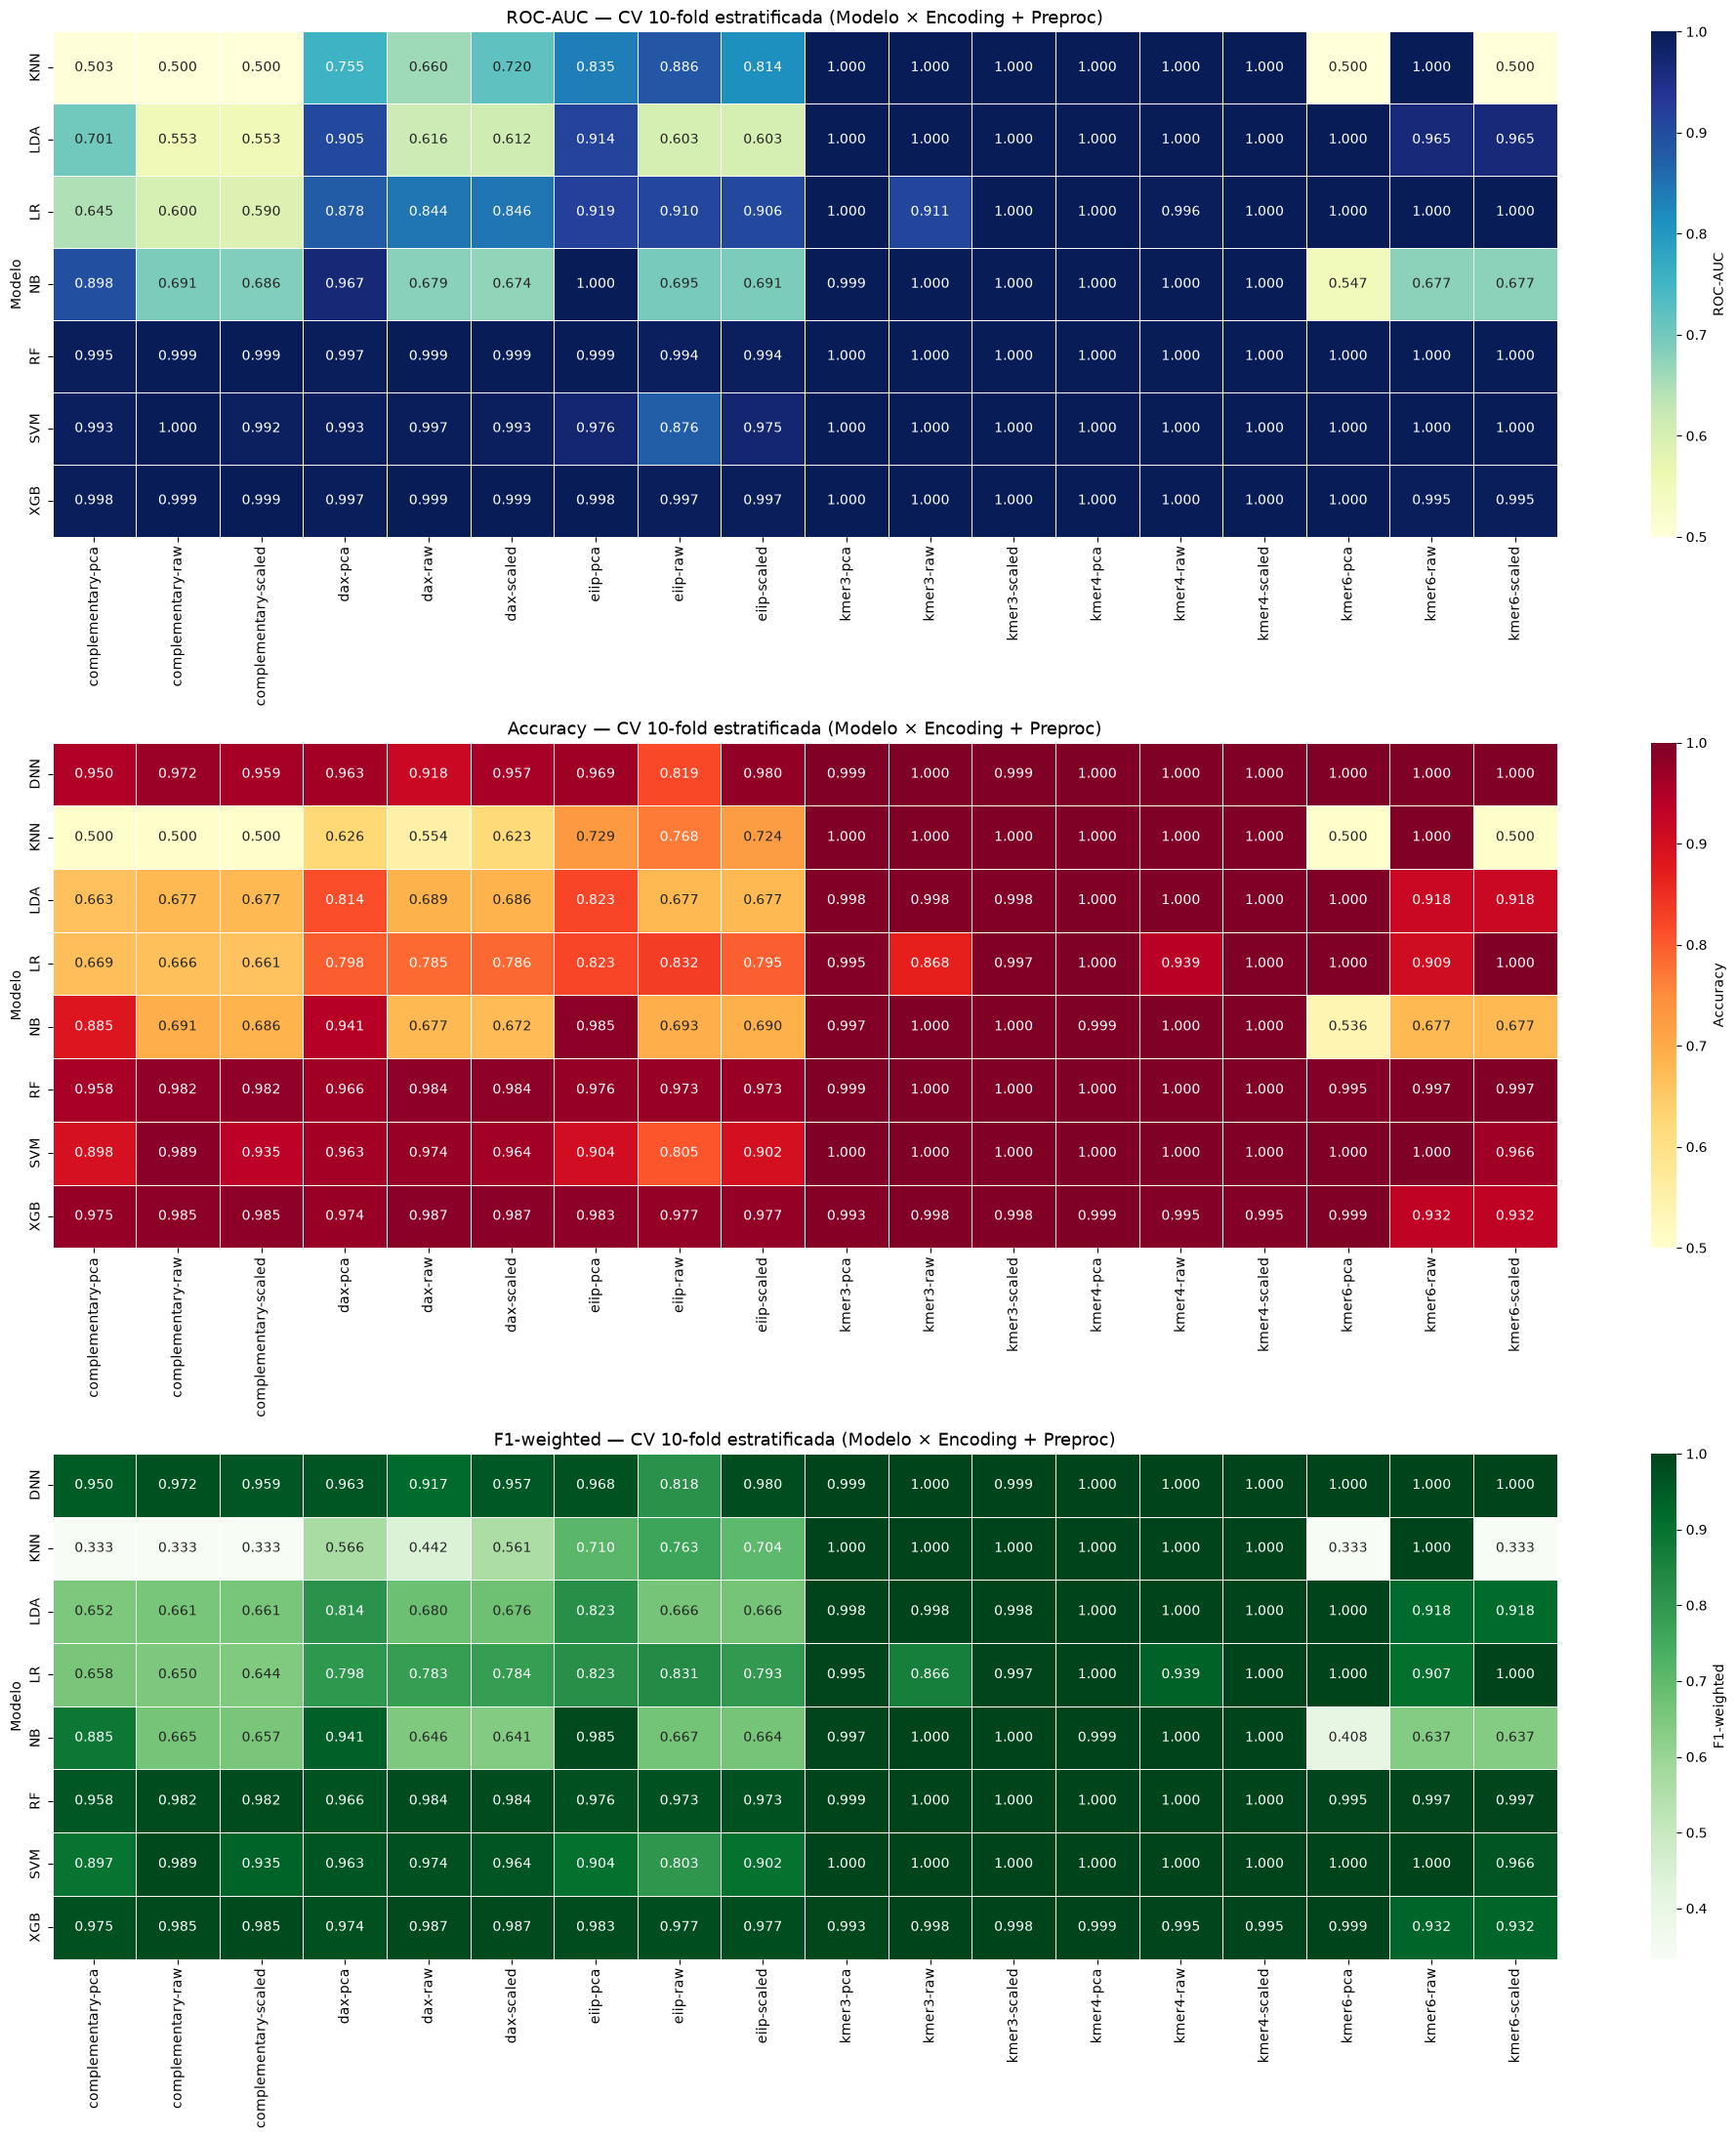

Figura guardada: /home/leandropanesso/projects/SimpleRepeatSeq/figures/fig1_heatmap_comparativo.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(20, 22))
for ax, pivot, title, cmap in zip(
    axes,
    [pivot_auc, pivot_acc, pivot_f1],
    ['ROC-AUC', 'Accuracy', 'F1-weighted'],
    ['YlGnBu', 'YlOrRd', 'Greens']
):
    sn.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
               cbar_kws={'label': title}, linewidths=0.5)
    ax.set_title(f'{title} — CV {N_SPLITS}-fold estratificada (Modelo × Encoding + Preproc)',
                 fontsize=13)
    ax.set_xlabel(''); ax.set_ylabel('Modelo')

plt.tight_layout()
path_fig1 = os.path.join(FIG_DIR, 'fig1_heatmap_comparativo.png')
plt.savefig(path_fig1, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_fig1}')

---
## Evaluación detallada — mejor configuración

Re-entrena con `cross_val_predict` (predicciones *out-of-fold*) para obtener
curva ROC, matriz de confusión y classification report **sin data leakage**.

In [9]:
best      = df_res.dropna(subset=['AUC']).sort_values('AUC', ascending=False).iloc[0]
BEST_ENC  = best['Encoding']
BEST_PRE  = best['Preproc']
BEST_MOD  = best['Modelo']

print(f'Mejor configuración: {BEST_MOD} | encoding={BEST_ENC} | preproc={BEST_PRE} | AUC={best["AUC"]:.4f}')

X_best = np.load(os.path.join(DATA_DIR, f'X_{BEST_ENC}.npy')).astype(np.float32)
y_best = np.load(os.path.join(DATA_DIR, 'y_labels.npy')).astype(int)

n_jobs_best = 1 if BEST_MOD == 'DNN' else -1
pipe_best   = build_pipeline(BEST_PRE, build_models()[BEST_MOD])

y_pred  = cross_val_predict(pipe_best, X_best, y_best, cv=kf_cv, n_jobs=n_jobs_best)
pipe_best2 = build_pipeline(BEST_PRE, build_models()[BEST_MOD])
y_proba = cross_val_predict(pipe_best2, X_best, y_best, cv=kf_cv,
                             n_jobs=n_jobs_best, method='predict_proba')[:, 1]

print('\nClassification report (out-of-fold):')
print(classification_report(y_best, y_pred, target_names=CLASES, digits=4))

Mejor configuración: RF | encoding=kmer4 | preproc=scaled | AUC=1.0000



Classification report (out-of-fold):
              precision    recall  f1-score   support

no_simpleSeq     1.0000    1.0000    1.0000       444
   simpleSeq     1.0000    1.0000    1.0000       444

    accuracy                         1.0000       888
   macro avg     1.0000    1.0000    1.0000       888
weighted avg     1.0000    1.0000    1.0000       888



### Figura 2 — Matriz de confusión (mejor modelo)

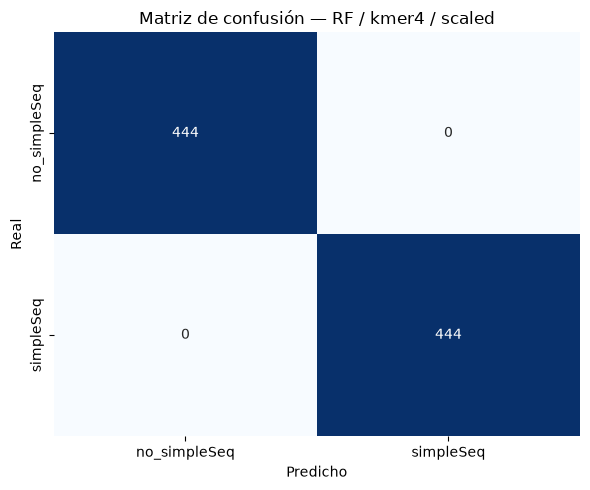

Figura guardada: /home/leandropanesso/projects/SimpleRepeatSeq/figures/fig2_confusion_best.png


In [10]:
cm = confusion_matrix(y_best, y_pred)
plt.figure(figsize=(6, 5))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=CLASES, yticklabels=CLASES, cbar=False)
plt.title(f'Matriz de confusión — {BEST_MOD} / {BEST_ENC} / {BEST_PRE}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout()
path_fig2 = os.path.join(FIG_DIR, 'fig2_confusion_best.png')
plt.savefig(path_fig2, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_fig2}')

### Figura 3 — Curvas ROC por encoding

Para cada encoding se elige el mejor modelo (cualquier preproc) y se traza su curva ROC con predicciones out-of-fold.

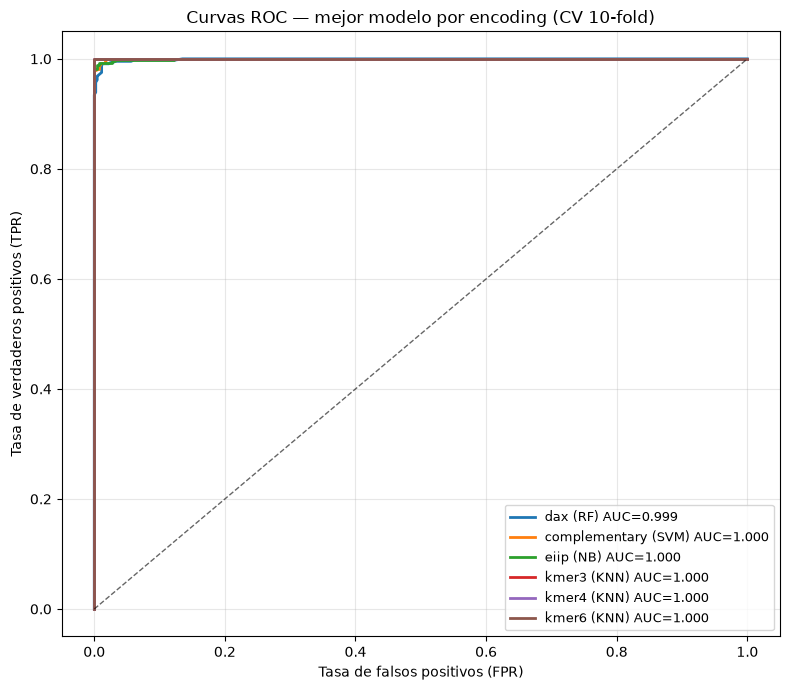

Figura guardada: /home/leandropanesso/projects/SimpleRepeatSeq/figures/fig3_roc_por_encoding.png


In [11]:
plt.figure(figsize=(8, 7))

for enc_name in ENCODINGS:
    sub = df_res[df_res['Encoding'] == enc_name].dropna(subset=['AUC'])
    if sub.empty:
        continue
    row = sub.sort_values('AUC', ascending=False).iloc[0]

    Xe = np.load(os.path.join(DATA_DIR, f'X_{enc_name}.npy')).astype(np.float32)
    ye = np.load(os.path.join(DATA_DIR, 'y_labels.npy')).astype(int)

    n_jobs_roc = 1 if row['Modelo'] == 'DNN' else -1
    pipe_roc   = build_pipeline(row['Preproc'], build_models()[row['Modelo']])
    proba      = cross_val_predict(pipe_roc, Xe, ye, cv=kf_cv,
                                   n_jobs=n_jobs_roc, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(ye, proba)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2,
             label=f'{enc_name} ({row["Modelo"]}) AUC={roc_auc:.3f}')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title(f'Curvas ROC — mejor modelo por encoding (CV {N_SPLITS}-fold)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
path_fig3 = os.path.join(FIG_DIR, 'fig3_roc_por_encoding.png')
plt.savefig(path_fig3, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_fig3}')

### Matrices de confusión — todos los modelos (mejor encoding)


----- KNN (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888




----- SVM (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888




----- LR (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888




----- LDA (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888




----- NB (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888




----- RF (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888




----- XGB (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      0.998     0.993     0.995       444
   simpleSeq      0.993     0.998     0.996       444

    accuracy                          0.995       888
   macro avg      0.996     0.995     0.995       888
weighted avg      0.996     0.995     0.995       888




----- DNN (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888



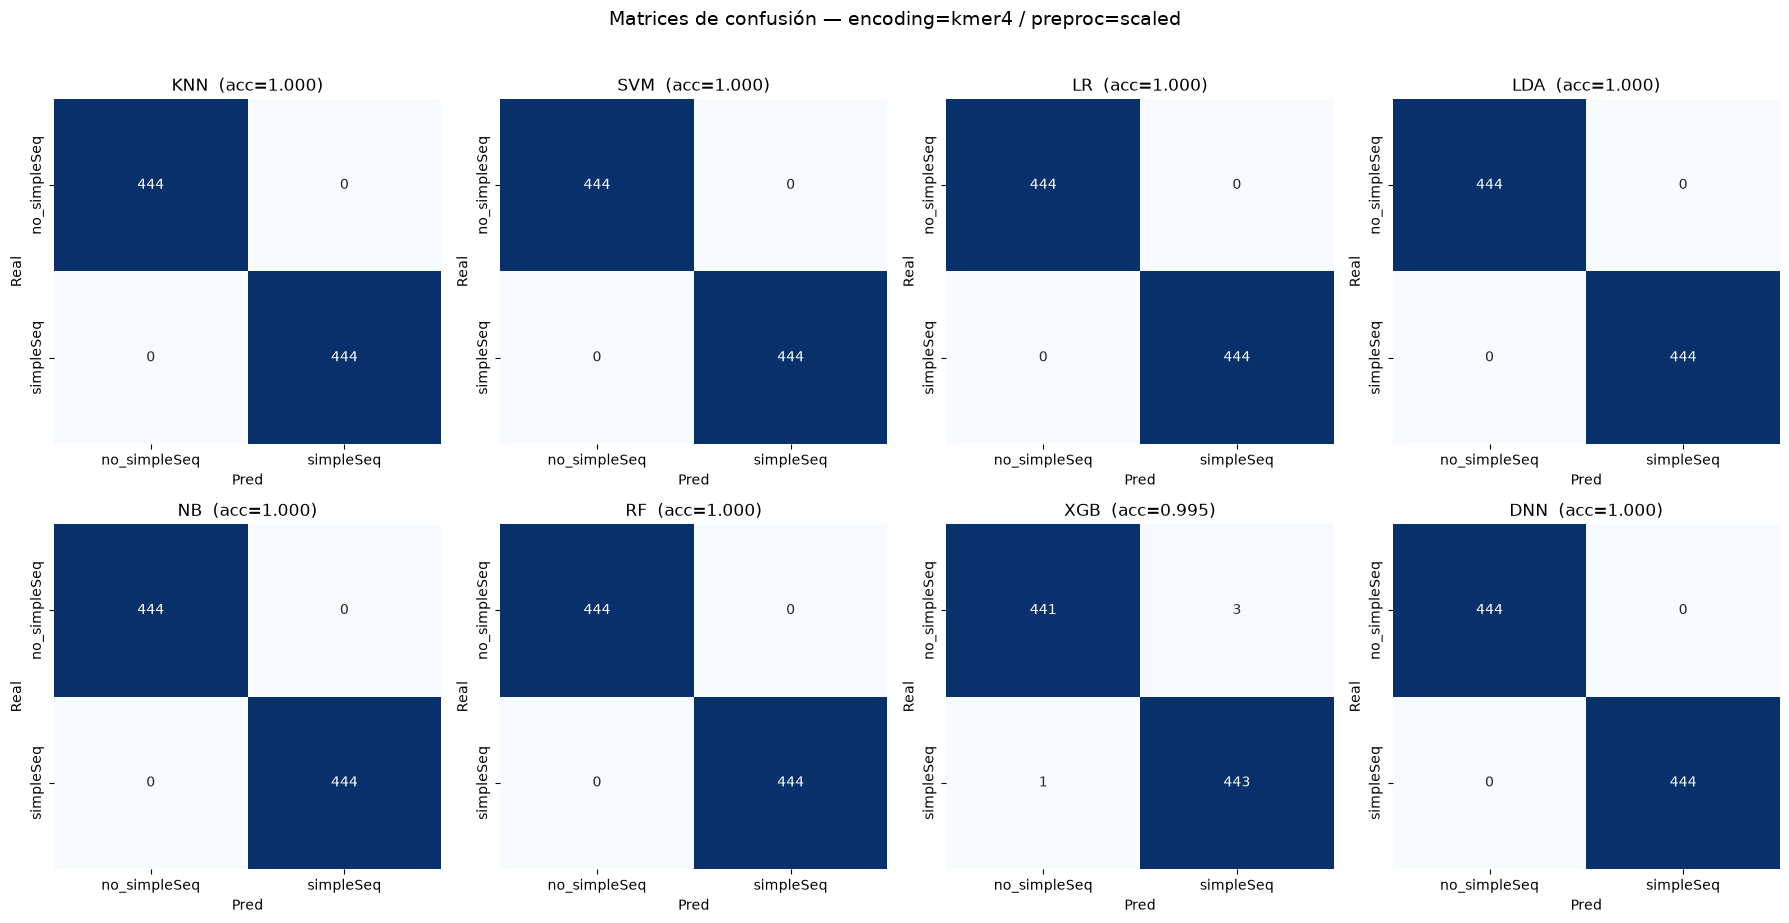

Figura guardada: /home/leandropanesso/projects/SimpleRepeatSeq/figures/fig_cm_todos_modelos.png


In [12]:
Xe = np.load(os.path.join(DATA_DIR, f'X_{BEST_ENC}.npy')).astype(np.float32)
ye = np.load(os.path.join(DATA_DIR, 'y_labels.npy')).astype(int)

modelos = list(build_models().keys())
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, mname in zip(axes, modelos):
    n_jobs_m = 1 if mname == 'DNN' else -1
    pipe_m   = build_pipeline(BEST_PRE, build_models()[mname])
    yp       = cross_val_predict(pipe_m, Xe, ye, cv=kf_cv, n_jobs=n_jobs_m)
    cm_m     = confusion_matrix(ye, yp)
    acc_m    = accuracy_score(ye, yp)
    sn.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=CLASES, yticklabels=CLASES, ax=ax)
    ax.set_title(f'{mname}  (acc={acc_m:.3f})')
    ax.set_xlabel('Pred'); ax.set_ylabel('Real')
    print(f'\n----- {mname} ({BEST_ENC}/{BEST_PRE}) -----')
    print(classification_report(ye, yp, target_names=CLASES, digits=3))

plt.suptitle(f'Matrices de confusión — encoding={BEST_ENC} / preproc={BEST_PRE}',
             fontsize=14, y=1.02)
plt.tight_layout()
path_cm = os.path.join(FIG_DIR, 'fig_cm_todos_modelos.png')
plt.savefig(path_cm, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_cm}')

### Figura 4 — Tiempo de entrenamiento vs. dimensionalidad

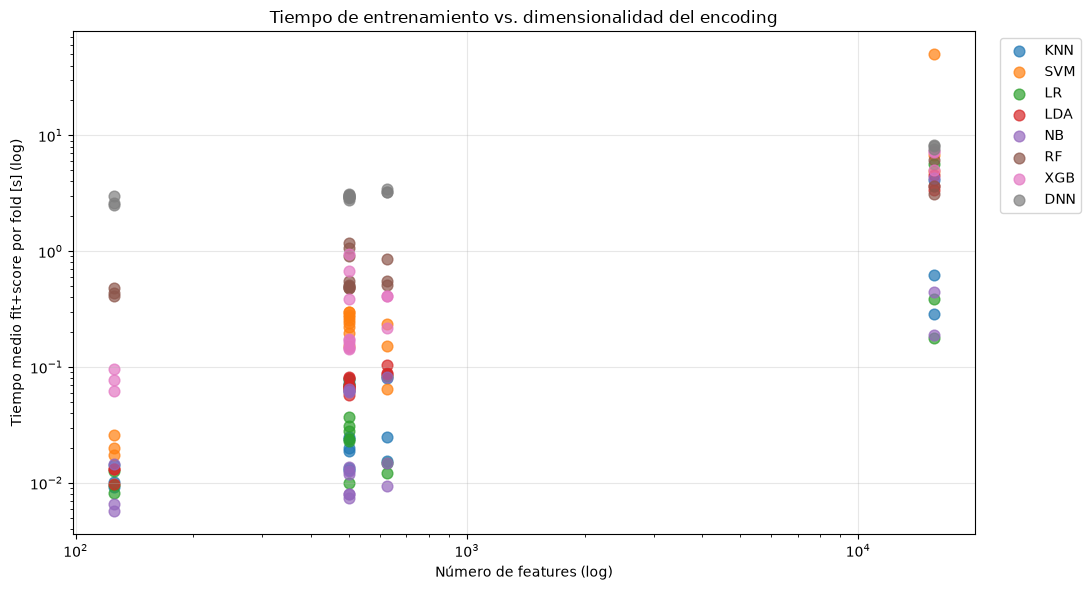

Figura guardada: /home/leandropanesso/projects/SimpleRepeatSeq/figures/fig4_tiempo_vs_features.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
for modelo in df_res['Modelo'].unique():
    sub = df_res[df_res['Modelo'] == modelo].dropna(subset=['Tiempo_s'])
    ax.scatter(sub['N_features'], sub['Tiempo_s'], label=modelo, s=60, alpha=0.7)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Número de features (log)')
ax.set_ylabel('Tiempo medio fit+score por fold [s] (log)')
ax.set_title('Tiempo de entrenamiento vs. dimensionalidad del encoding')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
path_fig4 = os.path.join(FIG_DIR, 'fig4_tiempo_vs_features.png')
plt.savefig(path_fig4, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_fig4}')

---
## Guardar mejor modelo

In [14]:
MAX_LEN   = 500  # longitud máxima del dataset (calculada en 01_load_data)
label_to_int = {'no_simpleSeq': 0, 'simpleSeq': 1}

X_full = np.load(os.path.join(DATA_DIR, f'X_{BEST_ENC}.npy')).astype(np.float32)
y_full = np.load(os.path.join(DATA_DIR, 'y_labels.npy')).astype(int)

final_pipe = build_pipeline(BEST_PRE, build_models()[BEST_MOD])
final_pipe.fit(X_full, y_full)

meta = {
    'encoding'    : BEST_ENC,
    'preproc'     : BEST_PRE,
    'modelo'      : BEST_MOD,
    'max_len'     : MAX_LEN,
    'clases'      : CLASES,
    'label_to_int': label_to_int,
}

model_path = os.path.join(MODEL_DIR, 'best_model.pkl')
joblib.dump({'pipeline': final_pipe, 'meta': meta}, model_path)
print(f'Modelo guardado: {model_path}')
print(f'Metadatos: {meta}')

Modelo guardado: /home/leandropanesso/projects/SimpleRepeatSeq/models/best_model.pkl
Metadatos: {'encoding': 'kmer4', 'preproc': 'scaled', 'modelo': 'RF', 'max_len': 500, 'clases': ['no_simpleSeq', 'simpleSeq'], 'label_to_int': {'no_simpleSeq': 0, 'simpleSeq': 1}}
